regula falsi method

Iteration	Root Approximation	Error
1	2.235294		7.647059e-01
2	2.304903		6.950971e-01
3	2.323878		6.761225e-01
4	2.328930		6.710703e-01
5	2.330266		6.697336e-01
6	2.330619		6.693806e-01
7	2.330713		6.692873e-01
8	2.330737		6.692627e-01
9	2.330744		6.692562e-01
10	2.330745		6.692545e-01
11	2.330746		6.692541e-01
12	2.330746		6.692540e-01
13	2.330746		6.692539e-01


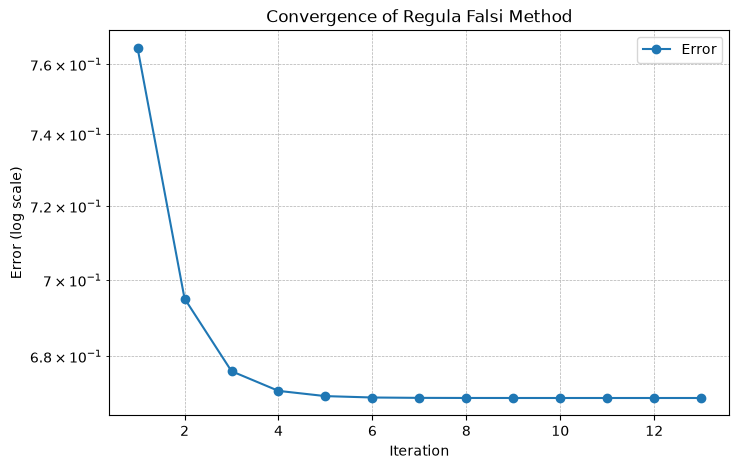

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def regula_falsi(f, x0, x1, tol=0.5e-6, max_iter=100):
    """
    Implements the Regula Falsi (False Position) method to find the root of f(x) = 0.

    Parameters:
        f (function): The function for which the root is to be found.
        x0 (float): The initial lower bound of the interval.
        x1 (float): The initial upper bound of the interval.
        tol (float): The tolerance for the stopping criterion.
        max_iter (int): The maximum number of iterations.

    Returns:
        root (float): The approximated root.
        error_table (list): A table of iterations, root approximations, and errors.
    """

    if f(x0) * f(x1) >= 0:
        raise ValueError("The function must have opposite signs at x0 and x1.")

    error_table = []

    for iteration in range(1, max_iter + 1):
        # Compute the root approximation using the formula
        x2 = x1 - (f(x1) * (x1 - x0)) / (f(x1) - f(x0))
        error = abs(x2 - x1)

        # Store iteration details
        error_table.append((iteration, x2, error))

        # Check for convergence
        if error < tol or abs(f(x2)) < tol:
            return x2, error_table

        # Update the interval
        if f(x2) * f(x0) < 0:
            x1 = x2
        else:
            x0 = x2

    raise RuntimeError("Maximum iterations exceeded without convergence.")


# Define the function for which we want to find the root and take care of initial guess
def f(x):
    # return x**2 - 4
    # return x**2 - 6*np.exp(-x)  # x^2 - 6exp(-x)
    # return x**2 - np.cos(x)     # x^2 - cos(x)
    return x**3 - 2*x - 8


# Initial guesses
x0, x1 = 2, 3

# Find the root and generate the error table
root, error_table = regula_falsi(f, x0, x1)

# Print the error table
print("Iteration\tRoot Approximation\tError")
for iteration, x2, error in error_table:
    print(f"{iteration}\t{x2:.6f}\t\t{error:.6e}")

# Plot the convergence
iterations = [row[0] for row in error_table]
errors = [row[2] for row in error_table]

plt.figure(figsize=(8, 5))
plt.plot(iterations, errors, marker='o', label='Error')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Error (log scale)')
plt.title('Convergence of Regula Falsi Method')
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

secant Method

Iteration	Root Approximation	Error
1	0.369266		1.630734e+00
2	0.618374		2.491082e-01
3	0.914480		2.961053e-01
4	0.812824		1.016554e-01
5	0.823586		1.076179e-02
6	0.824136		5.497027e-04
7	0.824132		3.501391e-06


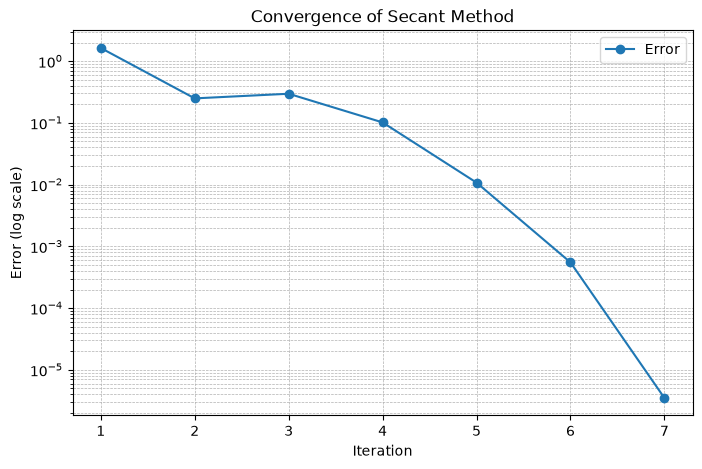

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def secant_method(f, x0, x1, tol=1e-6, max_iter=100):
    """
    Implements the Secant method to find the root of f(x) = 0.

    Parameters:
        f (function): The function for which the root is to be found.
        x0 (float): The first initial guess.
        x1 (float): The second initial guess.
        tol (float): The tolerance for the stopping criterion.
        max_iter (int): The maximum number of iterations.

    Returns:
        root (float): The approximated root.
        error_table (list): A table of iterations, root approximations, and errors.
    """

    error_table = []

    for iteration in range(1, max_iter + 1):
        # Compute the next approximation using the secant formula
        if f(x1) - f(x0) == 0:
            raise ZeroDivisionError("Division by zero encountered in the Secant method.")

        x2 = x1 - f(x1) * (x1 - x0) / (f(x1) - f(x0))
        error = abs(x2 - x1)

        # Store iteration details
        error_table.append((iteration, x2, error))

        # Check for convergence
        if error < tol or abs(f(x2)) < tol:
            return x2, error_table

        # Update the previous points
        x0, x1 = x1, x2

    raise RuntimeError("Maximum iterations exceeded without convergence.")


# Define the function for which we want to find the root
def f(x):
    # return x**2 - 4      # x^2-4
    # return x**3 - 2*x - 8  # x^3-2x-8
    # return x**2 - 6*np.exp(-x)  # x^2-6exp(-x)
    return x**2 - np.cos(x)


# Initial guesses
x0, x1 = 0, 2

# Find the root and generate the error table
root, error_table = secant_method(f, x0, x1)

# Print the error table
print("Iteration\tRoot Approximation\tError")
for iteration, x2, error in error_table:
    print(f"{iteration}\t{x2:.6f}\t\t{error:.6e}")

# Plot the convergence
iterations = [row[0] for row in error_table]
errors = [row[2] for row in error_table]

plt.figure(figsize=(8, 5))
plt.plot(iterations, errors, marker='o', label='Error')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Error (log scale)')
plt.title('Convergence of Secant Method')
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()